# Pooling, Normalisation & Activation Functions
## Annotated Code Walkthrough — ARI5118 Deep Learning for Computer Vision

This notebook walks through the three pillars of a modern CNN block using **PyTorch** and **OpenCV**.
Rather than reimplementing everything by hand, we use the library functions as they appear in real
projects — but we pause at each step to inspect intermediate outputs, visualise what is happening
spatially, and sweep over key parameters.

### Pipeline at a glance

```
Input image  →  Conv2d  →  Normalisation  →  Activation  →  Pooling  →  GAP  →  feature vector
```

### Sections

| # | Topic |
|---|-------|
| 1 | Setup and input preparation |
| 2 | Convolution — building feature maps to work with |
| 3 | **Pooling** — MaxPool, AvgPool, AdaptiveAvgPool (GAP), parameter sweeps |
| 4 | **Normalisation** — BatchNorm2d, LayerNorm, InstanceNorm2d, side-by-side comparison |
| 5 | **Activation Functions** — ReLU, LeakyReLU, ELU, GELU, dying-ReLU demo |
| 6 | Full configurable pipeline and ablation study |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

print(f"PyTorch : {torch.__version__}")
print(f"OpenCV  : {cv2.__version__}")
print(f"Device  : {'GPU' if torch.cuda.is_available() else 'CPU (no GPU required)'}")

PyTorch : 2.11.0+cu130
OpenCV  : 4.13.0
Device  : CPU (no GPU required)


## Section 1: Preparing the Input

We create a small synthetic image with three clearly distinct geometric regions so that the
spatial effect of pooling and normalisation is easy to see. We then build a **mini-batch of
four** images by adding small amounts of Gaussian noise to each copy — Batch Normalisation
requires a batch to compute meaningful statistics.

All images are converted to PyTorch tensors in **(N, C, H, W)** layout, which is the
standard convention throughout `torch.nn`. **(N, C, H, W)** follows the following order:
Number of samples, Channels, Height, and Width.

Batch shape: torch.Size([4, 3, 128, 128])  →  (N, C, H, W)


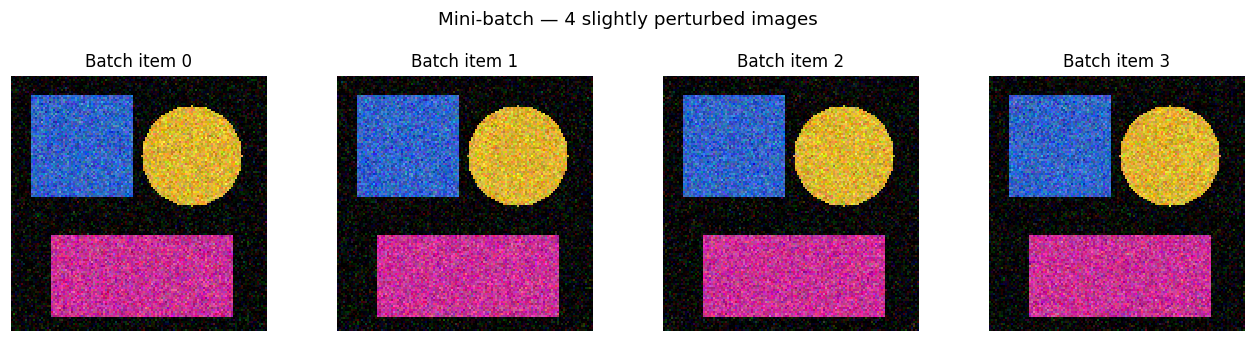

In [2]:
# build a synthetic 128×128 image with three regions
img_bgr = np.zeros((128, 128, 3), dtype=np.uint8)
cv2.rectangle(img_bgr, (10, 10), (60, 60), (200, 100,  50), -1)
cv2.circle(img_bgr, (90, 40), 25, ( 50, 180, 220), -1)
cv2.rectangle(img_bgr, (20, 80), (110, 120), (150,  50, 200), -1)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_float = torch.tensor(img_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0  # (3, 128, 128)

# dataset of 4 images (add Gaussian noise to each copy)
batch = torch.stack([
    torch.clamp(img_float + torch.randn_like(img_float) * 0.1, 0, 1)
    for _ in range(4)
]) # (4, 3, 128, 128)

print(f"Batch shape: {batch.shape}  →  (N, C, H, W)")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(batch[i].permute(1, 2, 0).numpy())
    ax.set_title(f"Batch item {i}")
    ax.axis("off")

plt.suptitle("Mini-batch — 4 slightly perturbed images", y=1.02)
plt.tight_layout()
plt.show()

## Section 2: Convolution

We use `nn.Conv2d` to apply three fixed kernels to the greyscale version of our image:
a horizontal Sobel, a vertical Sobel, and a Gaussian blur. These three channels become the
feature map that all subsequent operations act on.

> **Why fixed kernels here?** In a trained CNN the weights are learned. Using known kernels
> lets us predict and verify what each channel *should* look like — making the downstream
> effects of pooling and normalisation much easier to reason about.


Feature maps shape: torch.Size([1, 3, 128, 128])


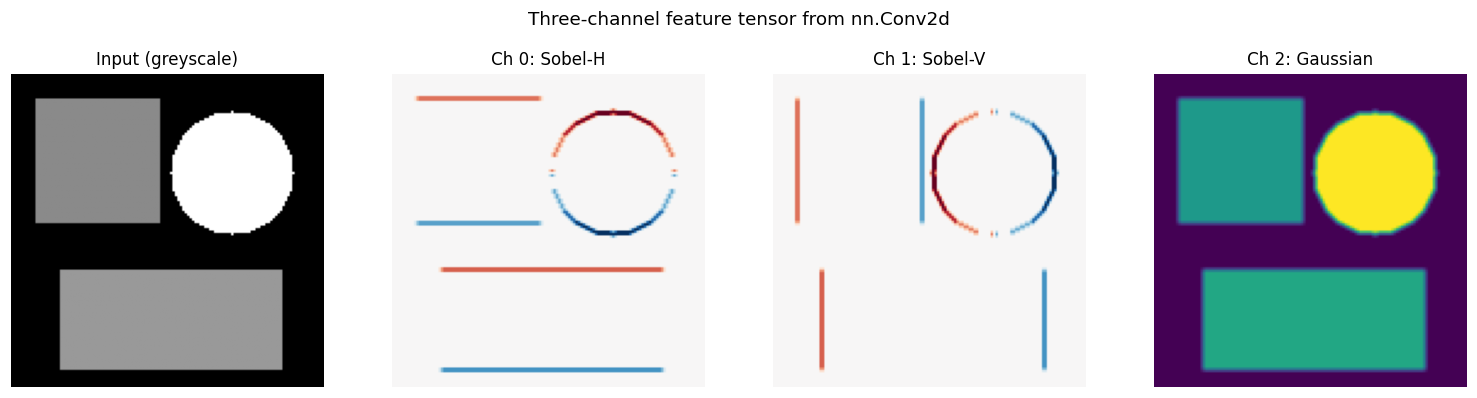

In [3]:
# convert to greyscale and add channel dimension.
grey = torch.tensor(
    cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), dtype=torch.float32
).unsqueeze(0).unsqueeze(0) / 255.0 # (1, 1, 128, 128)

# define three 3×3 kernels as a (3, 1, 3, 3) weight tensor
# Conv2d weight shape: (out_channels, in_channels, kH, kW)
sobel_h = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
sobel_v = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
gauss = torch.tensor(cv2.getGaussianKernel(3, 1.0), dtype=torch.float32)
gauss = (gauss @ gauss.T)

kernels = torch.stack([sobel_h, sobel_v, gauss]).unsqueeze(1) # (3, 1, 3, 3)

conv = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=3, padding=1, bias=False)
conv.weight = nn.Parameter(kernels, requires_grad=False)

with torch.no_grad():
    fmaps = conv(grey) # (1, 3, 128, 128)

print(f"Feature maps shape: {fmaps.shape}")

# visualise
titles = ["Input (greyscale)", "Ch 0: Sobel-H", "Ch 1: Sobel-V", "Ch 2: Gaussian"]
images = [grey[0,0]] + [fmaps[0,c] for c in range(3)]
cmaps = ["gray", "RdBu_r", "RdBu_r", "viridis"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, im, title, cm in zip(axes, images, titles, cmaps):
    ax.imshow(im.numpy(), cmap=cm)
    ax.set_title(title); ax.axis("off")

plt.suptitle("Three-channel feature tensor from nn.Conv2d", y=1.02)
plt.tight_layout(); plt.show()

## Section 3: Pooling

### Why pool?

After convolution, feature maps can be very large. Pooling **reduces spatial resolution**
while retaining the most important information. This:
- Makes the network invariant to small spatial shifts of a feature.
- Cuts the number of parameters in subsequent layers.

### Three variants

| Layer | PyTorch class | What it outputs |
|-------|---------------|-----------------|
| **Max pooling** | `nn.MaxPool2d` | The *strongest* activation in each window |
| **Average pooling** | `nn.AvgPool2d` | The *mean* activation in each window |
| **Global Avg Pooling** | `nn.AdaptiveAvgPool2d(1)` | One scalar per channel — collapses H and W entirely |

> **Analogy:** Imagine scanning a crowd photo looking for a red umbrella.
> Max pooling says *"was there a red umbrella anywhere in this block?"* — it
> preserves the strongest signal. Average pooling says *"how red was this block
> on average?"* — useful when colour density matters more than peak response.


Input shape: torch.Size([1, 3, 128, 128])
MaxPool2d(2,2): torch.Size([1, 3, 64, 64])
AvgPool2d(2,2): torch.Size([1, 3, 64, 64])
AdaptiveAvgPool2d: torch.Size([1, 3])  ← one value per channel
AdaptiveAvgPool2d Values: [-2.4432665668427944e-08, 0.0, 0.2375054806470871]


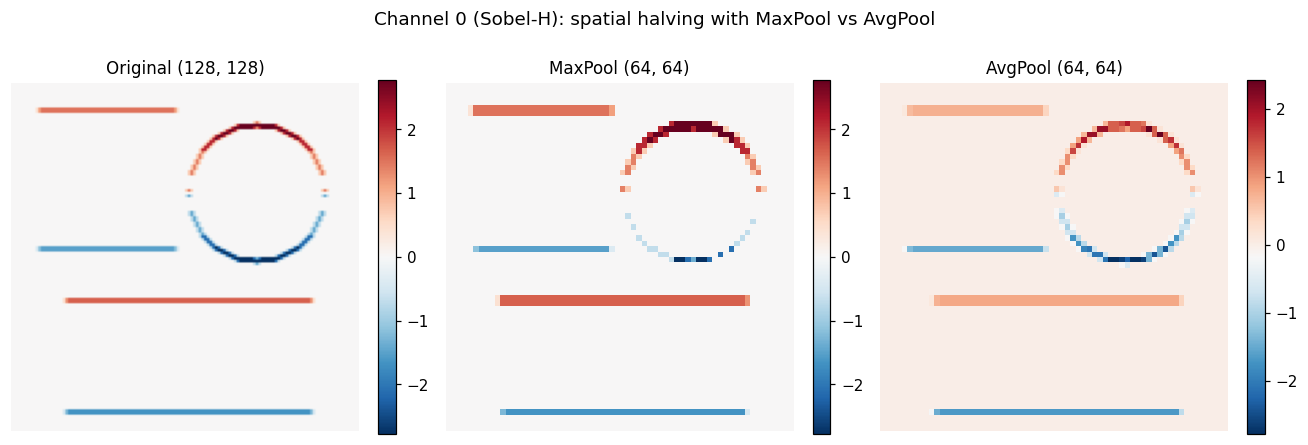

In [4]:
x = fmaps.detach() # (1, 3, 128, 128)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
gap = nn.AdaptiveAvgPool2d(output_size=1) # converts any input size → 1×1

out_max = max_pool(x) # (1, 3, 64, 64)
out_avg = avg_pool(x) # (1, 3, 64, 64)
out_gap = gap(x).squeeze(-1).squeeze(-1) # (1, 3)

print(f"Input shape: {x.shape}")
print(f"MaxPool2d(2,2): {out_max.shape}")
print(f"AvgPool2d(2,2): {out_avg.shape}")
print(f"AdaptiveAvgPool2d: {out_gap.shape}  ← one value per channel")
print(f"AdaptiveAvgPool2d Values: {out_gap.squeeze().tolist()}")

# side-by-side spatial comparison (channel 0 = Sobel-H)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, arr, title in zip(
        axes,
        [x[0,0], out_max[0,0], out_avg[0,0]],
        [f"Original {tuple(x.shape[2:])}", f"MaxPool {tuple(out_max.shape[2:])}", f"AvgPool {tuple(out_avg.shape[2:])}"]):
    im = ax.imshow(arr.numpy(), cmap="RdBu_r")
    ax.set_title(title); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Channel 0 (Sobel-H): spatial halving with MaxPool vs AvgPool", y=1.02)
plt.tight_layout(); plt.show()

### Parameter Sweep: `kernel_size` and `stride`

`kernel_size` sets how large each pooling window is.  
`stride` sets how far the window moves between steps.

- When `stride == kernel_size` the windows are non-overlapping (standard downsampling).
- When `stride < kernel_size` the windows overlap, producing a smoother but larger output.
- When `stride > kernel_size` you skip positions — the output can miss features entirely.


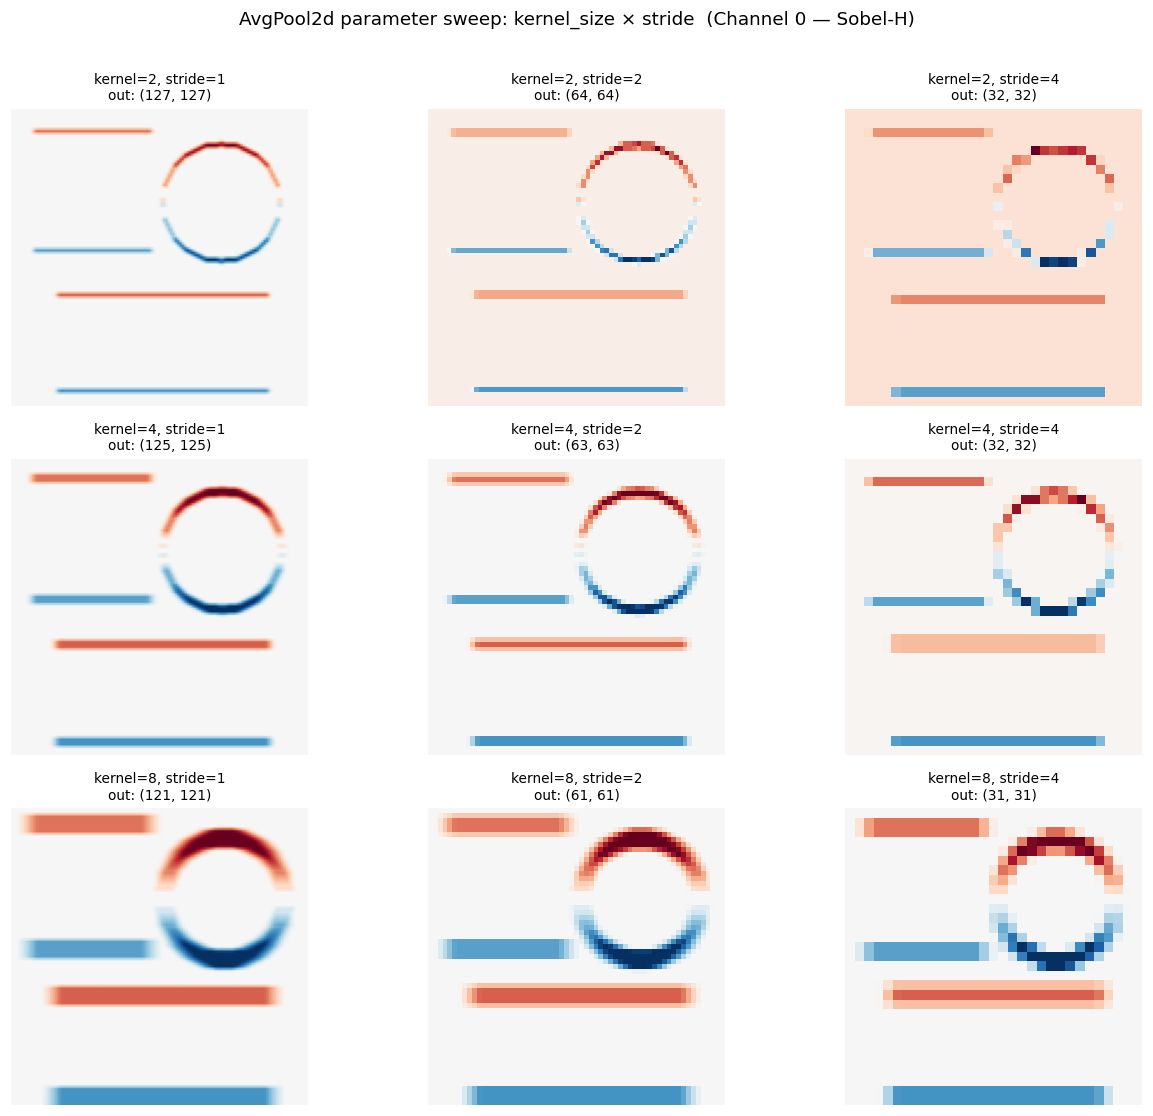

In [5]:
kernel_sizes = [2, 4, 8]
strides = [1, 2, 4]

fig, axes = plt.subplots(len(kernel_sizes), len(strides), figsize=(12, 10))

for row, ks in enumerate(kernel_sizes):
    for col, st in enumerate(strides):
        try:
            pooled = nn.AvgPool2d(kernel_size=ks, stride=st)(x)
            axes[row, col].imshow(pooled[0, 0].numpy(), cmap="RdBu_r")
            axes[row, col].set_title(
                f"kernel={ks}, stride={st}\nout: {tuple(pooled.shape[2:])}", fontsize=9)
        except Exception as e:
            axes[row, col].text(0.5, 0.5, str(e), ha="center", va="center", fontsize=7)
        axes[row, col].axis("off")

plt.suptitle("AvgPool2d parameter sweep: kernel_size × stride  (Channel 0 — Sobel-H)",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

### Max vs Average Pooling: When Does It Matter?

Max pooling and average pooling give very different results when a feature map contains
a **sparse, strong spike** (e.g., an edge response) surrounded by weak background activations.

Let's build an 8x8 feature map with a 1x1 strong spike (against a weak background).
Then, let's compare the difference between avg/max pooling with hyperparameters size 2, stride 2.


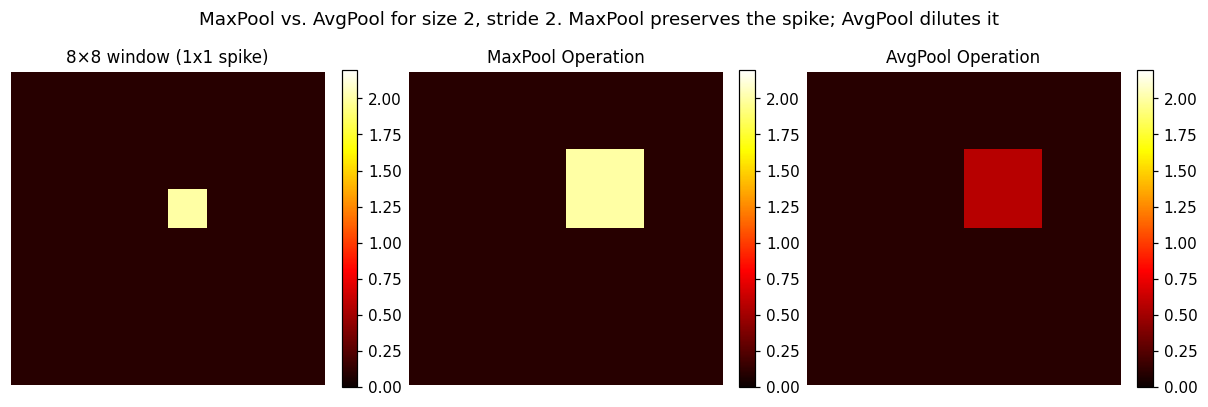

In [6]:
# build a controlled 8x8 feature map with a weak background but one (1x1) strong spike
window = torch.ones(1, 1, 8, 8) * 0.1
window[0, 0, 3, 4] = 2

kernel_size=2
stride=2

out_max_w = nn.MaxPool2d(kernel_size=kernel_size, stride=stride)(window)
out_avg_w = nn.AvgPool2d(kernel_size=kernel_size, stride=stride)(window)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, data, title in zip(
        axes,
        [window[0,0], out_max_w[0,0], out_avg_w[0,0]],
        ["8×8 window (1x1 spike)", f"MaxPool Operation", f"AvgPool Operation"]):
    im = ax.imshow(data.numpy(), cmap="hot", vmin=0, vmax=2.2)
    ax.set_title(title); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("MaxPool vs. AvgPool for size 2, stride 2. MaxPool preserves the spike; AvgPool dilutes it", y=1.02)
plt.tight_layout(); plt.show()

## Section 4: Normalisation

### Why normalise?

Without normalisation, activations can **explode** or **vanish** as they propagate through
many layers. The distribution of each layer's inputs also shifts during training as the
weights of the previous layer change — a problem Ioffe & Szegedy (2015) called
**internal covariate shift**.

Normalisation re-centres and re-scales the activations. The general formula is:

$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}}$$

followed by a **learned affine rescale** (γ and β) so the network can undo the
normalisation if needed:

$$y = \gamma \hat{x} + \beta$$

In [7]:
bn = nn.BatchNorm2d(num_features=3, eps=1e-5, momentum=0.1)
bn.train()  # uses actual batch mean and variance
with torch.no_grad():
    out_bn = bn(batch)

def batch_stats(t, label):
    v = t[:, 0] # all samples, channel 0 → shape (4, 128, 128)
    print(f"{label:<20}  mean={v.mean():.5f}  std={v.std():.4f}  "
          f"min={v.min():.3f}  max={v.max():.3f}")

print(f"{'Method':<20}  {'mean':>9}  {'std':>7}  {'min':>7}  {'max':>7}")
print("-" * 60)
batch_stats(batch,  "Raw input")
batch_stats(out_bn, "BatchNorm2d")

print("\nAs can be seen, after applying the batch normalisation, the batch data is centered around mean 0 and variance 1.")

Method                     mean      std      min      max
------------------------------------------------------------
Raw input             mean=0.33233  std=0.3624  min=0.000  max=1.000
BatchNorm2d           mean=-0.00000  std=1.0000  min=-0.917  max=1.843

As can be seen, after applying the batch normalisation, the batch data is centered around mean 0 and variance 1.


### Why Batch Size Matters for Batch Normalisation

Batch Norm computes μ and σ *across the entire batch*. With a small batch those estimates
are noisy — exactly like estimating the mean of a population from only 1 or 2 samples.

- Batch ≥ 32: stable statistics, training is well-behaved.
- Batch 1–8: estimates are noisy; training can diverge.
- **Batch = 1**: mean = x, std ≈ 0 → normalised output is always 0. The layer learns nothing.

Let's estimate how batch sizes affect the quality of batch normalisation statistics.
We do this by getting the true mean and variance of all the 4 images in the batch.
Then, we use different batch sizes and compute the batch mean & variance and compare with
the true mean and variance.

/tmp/ipykernel_8987/3116128421.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([errors[bs] for bs in batch_sizes], labels=batch_sizes)


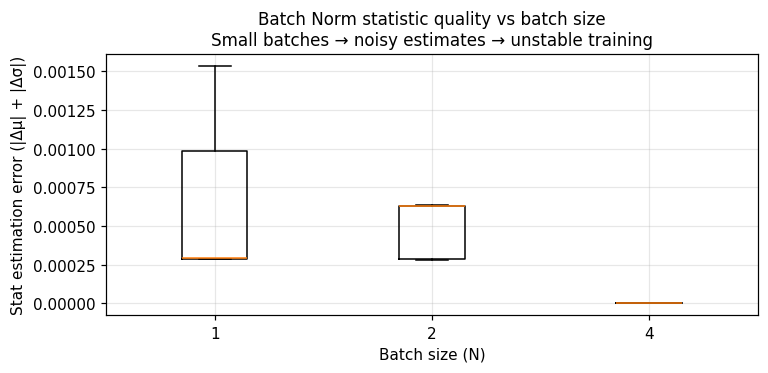

True channel 0:  mean=0.3323  std=0.3624
  Batch=1: mean error = 0.0008
  Batch=2: mean error = 0.0005
  Batch=4: mean error = 0.0000


In [8]:
true_mean = batch[:, 0].mean().item()
true_std = batch[:, 0].std().item()

batch_sizes = [1, 2, 4]
errors = {bs: [] for bs in batch_sizes}
n_trials = 200

for _ in range(n_trials):
    for bs in batch_sizes:
        sample = batch[torch.randperm(4)[:bs], 0] # random sub-batch
        errors[bs].append(abs(sample.mean().item() - true_mean) +
                          abs(sample.std().item()  - true_std))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot([errors[bs] for bs in batch_sizes], labels=batch_sizes)
ax.set_xlabel("Batch size (N)")
ax.set_ylabel("Stat estimation error (|Δμ| + |Δσ|)")
ax.set_title("Batch Norm statistic quality vs batch size\n"
             "Small batches → noisy estimates → unstable training")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"True channel 0:  mean={true_mean:.4f}  std={true_std:.4f}")
for bs in batch_sizes:
    print(f"  Batch={bs}: mean error = {np.mean(errors[bs]):.4f}")

## Section 5: Activation Functions

Without non-linear activation functions, stacking convolution layers reduces to a single
affine transform — no matter how deep the network is. Activations introduce the
non-linearity that allows networks to learn curved, complex decision boundaries.

### Functions we cover

| PyTorch class | Formula | Key property |
|---------------|---------|--------------|
| `nn.ReLU` | `max(0, x)` | Sparse, fast; can "die" |
| `nn.LeakyReLU(α)` | `x if x≥0 else αx` | Never fully dead |
| `nn.GELU` | `x · Φ(x)` | Soft probabilistic gate; used in GPT, BERT, ViT |
| `nn.Sigmoid` | `1/(1+e⁻ˣ)` | Output ∈ (0,1); mostly in output layers |


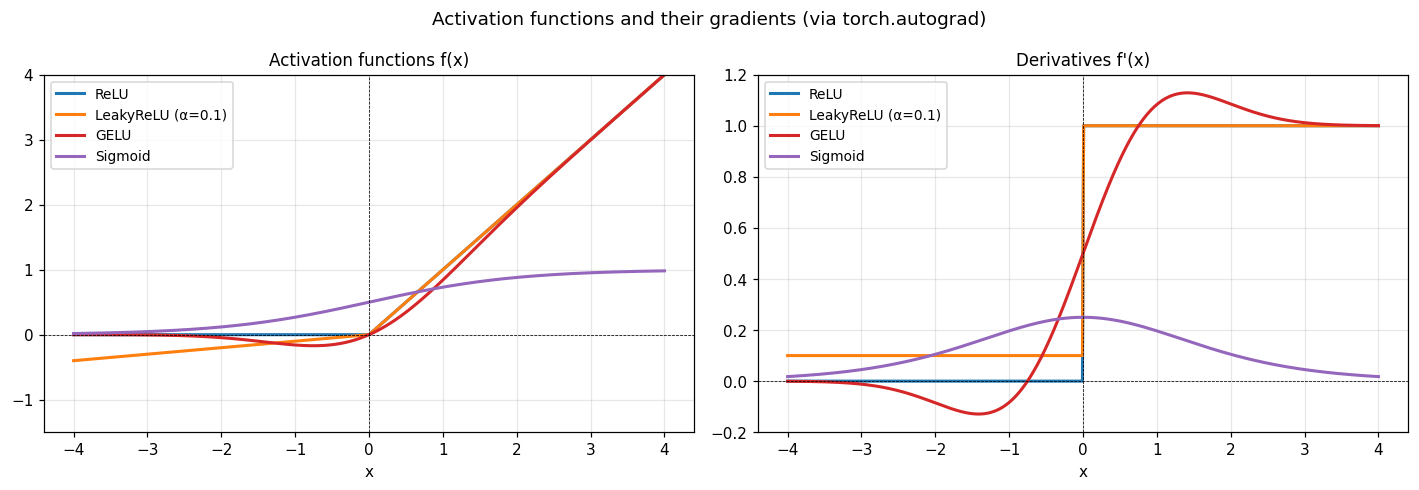

In [9]:
x_vals = torch.linspace(-4, 4, 500, requires_grad=True)

activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU (α=0.1)": nn.LeakyReLU(0.1),
    "GELU": nn.GELU(),
    "Sigmoid": nn.Sigmoid(),
}
colors = ["tab:blue", "tab:orange", "tab:red", "tab:purple"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for (name, fn), color in zip(activations.items(), colors):
    y = fn(x_vals)
    # Compute gradient for each x via autograd
    grad = torch.autograd.grad(y.sum(), x_vals, create_graph=False)[0]
    axes[0].plot(x_vals.detach(), y.detach(),    label=name, color=color, linewidth=2)
    axes[1].plot(x_vals.detach(), grad.detach(), label=name, color=color, linewidth=2)

for ax, title in zip(axes, ["Activation functions f(x)", "Derivatives f'(x)"]):
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_xlabel("x"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_title(title)
axes[0].set_ylim(-1.5, 4)
axes[1].set_ylim(-0.2, 1.2)

plt.suptitle("Activation functions and their gradients (via torch.autograd)", fontsize=12)
plt.tight_layout(); plt.show()


### Parameter Sweep: LeakyReLU Negative Slope α

The `α` parameter controls how much signal is preserved for negative inputs.

- `α = 0` → identical to ReLU; negative inputs produce zero output and zero gradient.
- `α = 1` → a perfectly linear function; no non-linearity at all.
- Typical values: `0.01` (classic Leaky ReLU) to `0.2` (DCGAN discriminator).


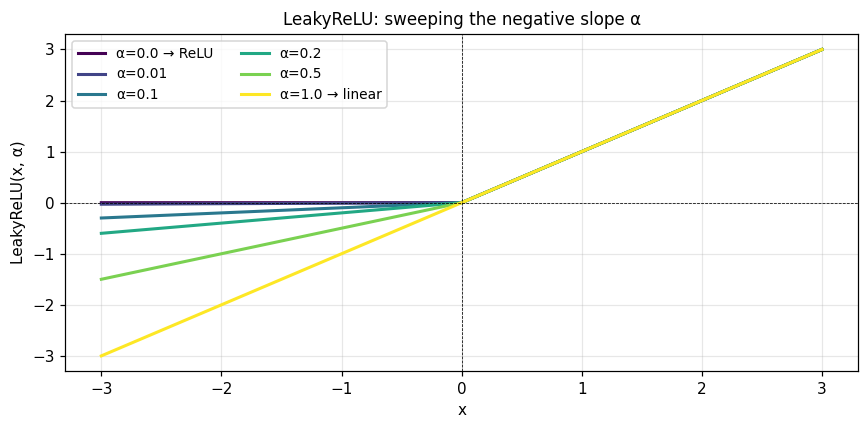

In [10]:
alphas = [0.0, 0.01, 0.1, 0.2, 0.5, 1.0]
x_vals = torch.linspace(-3, 3, 300)
cmap_fn = plt.cm.viridis(np.linspace(0, 1, len(alphas)))

fig, ax = plt.subplots(figsize=(8, 4))
for alpha, color in zip(alphas, cmap_fn):
    label = f"α={alpha}" + (" → ReLU" if alpha==0 else " → linear" if alpha==1 else "")
    y = nn.LeakyReLU(alpha)(x_vals)
    ax.plot(x_vals, y.detach(), label=label, color=color, linewidth=2)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("x"); ax.set_ylabel("LeakyReLU(x, α)")
ax.set_title("LeakyReLU: sweeping the negative slope α")
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### The Dying ReLU Problem

A ReLU neuron "dies" when its pre-activation value is **always negative** — for every
input in the dataset. Because the gradient of ReLU at x < 0 is exactly zero, no weight
update can revive it. The neuron is permanently off.

**Common causes:** A large learning rate spike, a very negative bias, or poor weight
initialisation can push a neuron into the dead zone permanently.

We simulate this by applying a large negative shift to the pre-activations.


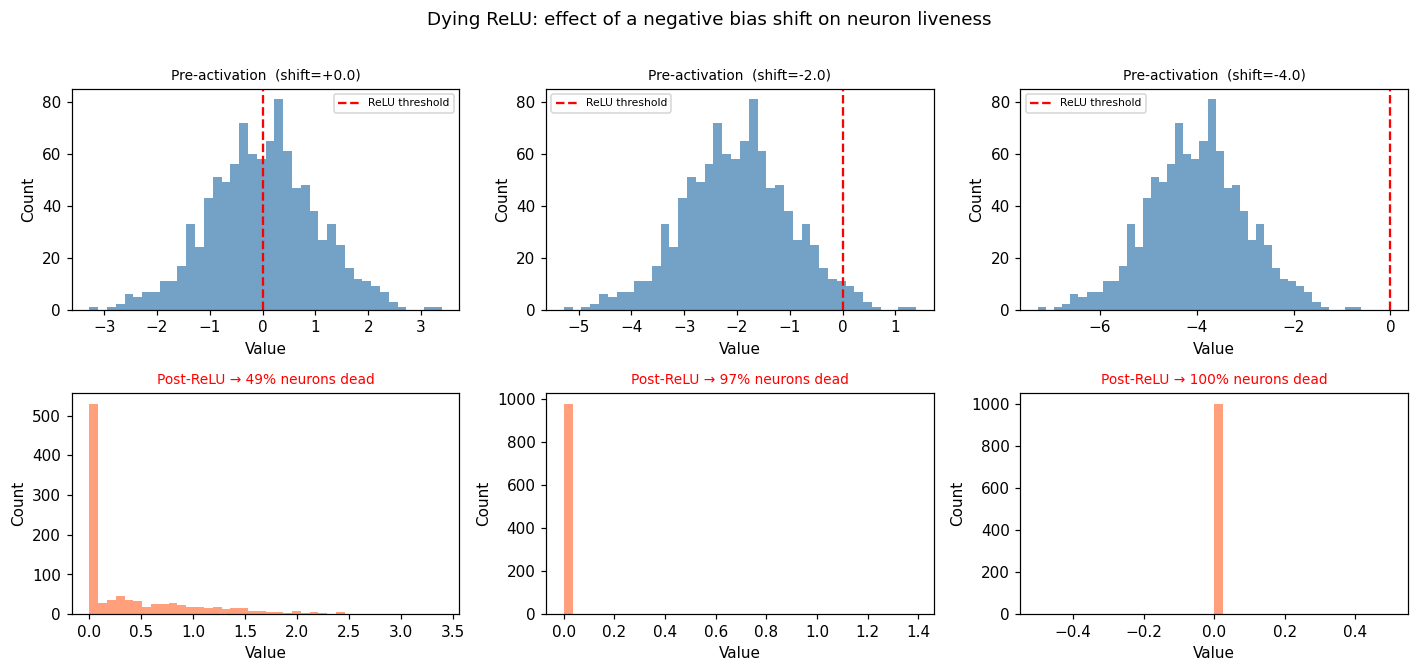

In [11]:
pre_activations = torch.randn(1000)   # random pre-activations (normal initialisation)
shifts = [0.0, -2.0, -4.0]
relu = nn.ReLU()

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for col, shift in enumerate(shifts):
    pre = pre_activations + shift
    post = relu(pre)
    dead = (post == 0).float().mean().item() * 100

    axes[0, col].hist(pre.numpy(), bins=40, color="steelblue", alpha=0.75, edgecolor="none")
    axes[0, col].axvline(0, color="red", linestyle="--", linewidth=1.5, label="ReLU threshold")
    axes[0, col].set_title(f"Pre-activation  (shift={shift:+.1f})", fontsize=9)
    axes[0, col].legend(fontsize=7)

    axes[1, col].hist(post.numpy(), bins=40, color="coral", alpha=0.75, edgecolor="none")
    colour = "red" if dead > 40 else "black"
    axes[1, col].set_title(f"Post-ReLU → {dead:.0f}% neurons dead", fontsize=9, color=colour)

for ax in axes.ravel():
    ax.set_xlabel("Value"); ax.set_ylabel("Count")

plt.suptitle("Dying ReLU: effect of a negative bias shift on neuron liveness", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

### Applying Activations to Real Feature Maps

Let's apply each activation to the Sobel-H channel (which has both positive and
negative values) and observe how the spatial map and value distribution change.

ReLU throws away the entire negative half of the Sobel response — losing information
about edges of one polarity. GELU applies a soft, probabilistic suppression that
preserves more of the signal.


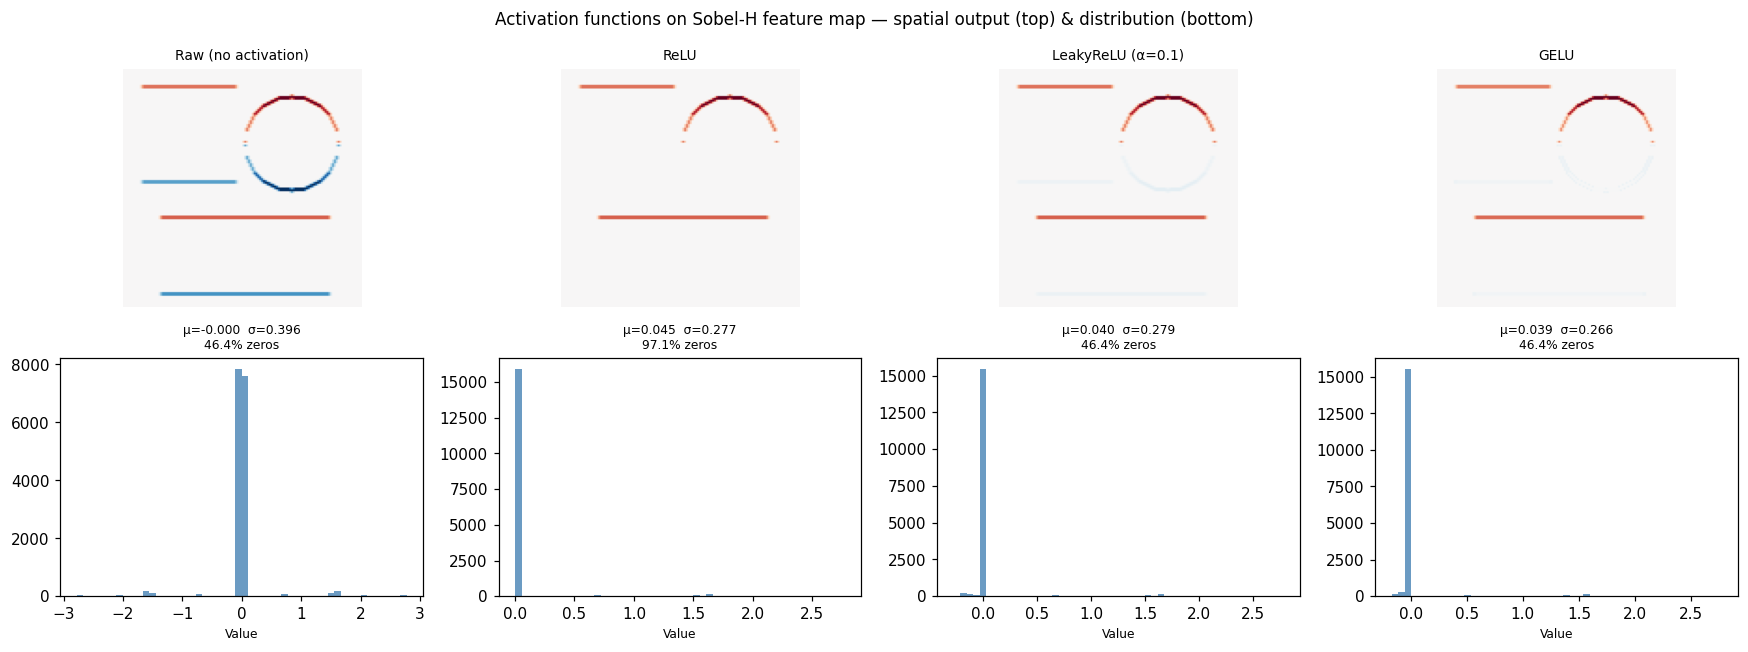

In [12]:
raw_fm = fmaps[0, 0].detach() # (128, 128)  Sobel-H channel

act_results = {
    "Raw (no activation)": raw_fm,
    "ReLU": nn.ReLU()(raw_fm),
    "LeakyReLU (α=0.1)": nn.LeakyReLU(0.1)(raw_fm),
    "GELU": nn.GELU()(raw_fm),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
vmax = raw_fm.abs().max().item()

for col, (name, fm) in enumerate(act_results.items()):
    fm_np = fm.numpy()
    axes[0, col].imshow(fm_np, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[0, col].set_title(name, fontsize=9); axes[0, col].axis("off")
    pct_zero = (fm_np == 0).mean() * 100
    axes[1, col].hist(fm_np.ravel(), bins=50, color="steelblue", alpha=0.8, edgecolor="none")
    axes[1, col].set_title(f"μ={fm_np.mean():.3f}  σ={fm_np.std():.3f}\n{pct_zero:.1f}% zeros",
                           fontsize=8)
    axes[1, col].set_xlabel("Value", fontsize=8)

plt.suptitle("Activation functions on Sobel-H feature map — spatial output (top) & distribution (bottom)",
             fontsize=11)
plt.tight_layout(); plt.show()


## Section 6: Full Configurable Pipeline

We now assemble everything into a single `nn.Sequential` block and run a small
**ablation study** — systematically varying the normalisation and activation choice
while keeping everything else fixed.

```
Conv2d (3 kernels)  →  Norm  →  Activation  →  MaxPool2d  →  AdaptiveAvgPool2d(1)
                                                                        ↓
                                                               feature vector (length 3)
```

In a real network this vector would feed a linear classifier.


In [13]:
def build_pipeline(norm_layer, act_layer, pool_size=2):
    """Assemble a Conv → Norm → Act → Pool → GAP block using nn.Sequential."""
    layers = [conv]                              # reuse our fixed-kernel conv
    if norm_layer is not None:
        layers.append(norm_layer)
    layers.append(act_layer)
    layers.append(nn.MaxPool2d(pool_size, stride=pool_size))
    layers.append(nn.AdaptiveAvgPool2d(1))       # → (N, C, 1, 1)
    return nn.Sequential(*layers)


# ── Ablation: 2 norms × 3 activations ────────────────────────────────────────
norm_options = {
    "BatchNorm2d":    nn.BatchNorm2d(3),
    "None":           None,
}
act_options = {
    "ReLU":         nn.ReLU(),
    "LeakyReLU":    nn.LeakyReLU(0.1),
    "GELU":         nn.GELU(),
}

print(f"{'Norm':<16}{'Activation':<14}{'Ch0':>9}{'Ch1':>9}{'Ch2':>9}  {'L2':>8}")
print("-" * 62)

all_results = []
with torch.no_grad():
    for nname, nfn in norm_options.items():
        for aname, afn in act_options.items():
            pipe = build_pipeline(nfn, afn)
            gap = pipe(grey).squeeze()        # (3,)
            l2 = gap.norm().item()
            all_results.append((nname, aname, gap.numpy(), l2))
            print(f"{nname:<16}{aname:<14}"
                  f"{gap[0].item():>9.4f}{gap[1].item():>9.4f}{gap[2].item():>9.4f}"
                  f"  {l2:>8.4f}")

Norm            Activation          Ch0      Ch1      Ch2        L2
--------------------------------------------------------------
BatchNorm2d     ReLU             0.2198   0.1902   0.4815    0.5624
BatchNorm2d     LeakyReLU        0.2110   0.1832   0.4375    0.5191
BatchNorm2d     GELU             0.2193   0.1899   0.3336    0.4420
None            ReLU             0.0871   0.0668   0.2475    0.2708
None            LeakyReLU        0.0837   0.0644   0.2475    0.2691
None            GELU             0.0809   0.0620   0.1697    0.1979


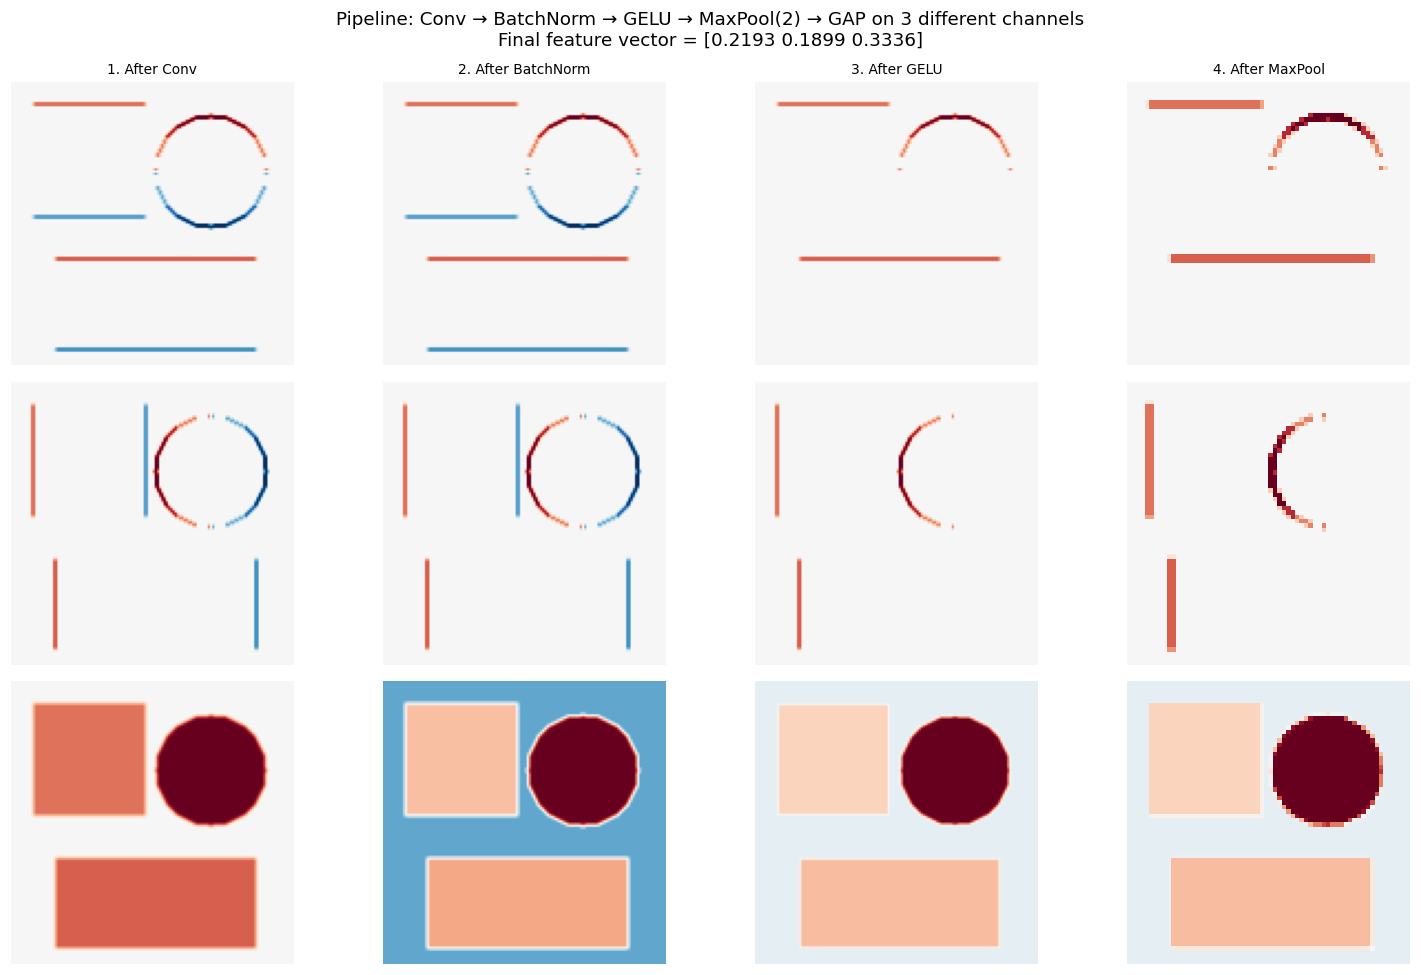

In [14]:
# visualise results for BatchNorm2d + GELU + MaxPool2d(2)
stages = {}

with torch.no_grad():
    stages["1. After Conv"] = fmaps[0] # (3, H, W)
    stages["2. After BatchNorm"]= nn.BatchNorm2d(3)(fmaps)[0]
    gn = nn.GELU()
    stages["3. After GELU"] = gn(stages["2. After BatchNorm"])
    stages["4. After MaxPool"] = nn.MaxPool2d(2,2)(stages["3. After GELU"].unsqueeze(0))[0]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for col, (stage, fmap) in enumerate(stages.items()):
    for row in range(3):
        fm = fmap[row].numpy()
        vmax = np.abs(fm).max() or 1e-6
        axes[row, col].imshow(fm, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[row, col].set_ylabel(f"Ch {row}", fontsize=8)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(stage, fontsize=9)

gap_final = nn.AdaptiveAvgPool2d(1)(stages["4. After MaxPool"].unsqueeze(0)).squeeze()
plt.suptitle(
    f"Pipeline: Conv → BatchNorm → GELU → MaxPool(2) → GAP on 3 different channels\n"
    f"Final feature vector = {gap_final.numpy().round(4)}",
    fontsize=12)
plt.tight_layout(); plt.show()

## Summary

| Component | PyTorch class | Key design decision |
|-----------|--------------|-------------------|
| Convolution | `nn.Conv2d` | kernel_size, stride, padding |
| Max pooling | `nn.MaxPool2d` | kernel_size, stride; preserves peaks |
| Average pooling | `nn.AvgPool2d` | kernel_size, stride; preserves average energy |
| Global avg pool | `nn.AdaptiveAvgPool2d(1)` | Replaces flatten + FC; output size is fixed regardless of input |
| Batch Norm | `nn.BatchNorm2d` | Requires N ≥ 16 for stable statistics; use `train()` / `eval()` correctly |
| ReLU | `nn.ReLU` | Default starting point; watch for dying neurons |
| Leaky ReLU | `nn.LeakyReLU(α)` | α=0.01–0.1 prevents neuron death |
| GELU | `nn.GELU` | Soft gate; state-of-the-art in modern architectures |